In [7]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from keras.datasets import cifar10
from keras.applications import ResNet50, DenseNet121, VGG16,  EfficientNetB0
import optuna
import optuna.visualization as vis
from keras.losses import SparseCategoricalCrossentropy

In [8]:
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    print('Running on TPU ', tpu.master())
except ValueError:
    tpu = None

if tpu:
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
else:
    strategy = tf.distribute.MirroredStrategy() 

Running on TPU  
INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.
INFO:tensorflow:Initializing the TPU system: local
INFO:tensorflow:Finished initializing TPU system.
INFO:tensorflow:Found TPU system:
INFO:tensorflow:*** Num TPU Cores: 8
INFO:tensorflow:*** Num TPU Workers: 1
INFO:tensorflow:*** Num TPU Cores Per Worker: 8
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:CPU:0, CPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:0, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:1, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:2, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:3, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/

In [9]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train = X_train / 255
X_test = X_test / 255

X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train)

# Creating a baseline model

for this baseline model I will be using the same layers in the head of the convolutional neural network from my custom model. This head will likely not translate very well to work with the ResNet50 base so afterwards I will be creating a new model using optuna to hyperparameter tune the layers in the head.

In [10]:
with strategy.scope():
    
    dense_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    dense_base.trainable = False
    
    inputs = keras.Input(shape=(32, 32, 3))
    
    x = dense_base(inputs)
    
    x = layers.Flatten()(x)
    x = layers.Dense(342, activation='relu') (x)
#     x = layers.Dropout(.49155865824030837)(x)
    output = layers.Dense(10)(x)
    
    base_model = keras.Model(inputs=inputs, outputs=output, name='baseline_model_with_resnet')
    base_model.compile(
        optimizer='adam',
        loss=SparseCategoricalCrossentropy(from_logits=True),
        metrics=['sparse_categorical_accuracy']
    )


I0000 00:00:1727461157.672950    1431 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [11]:
keras.utils.plot_model(base_model, 'baseline_model_with_resnet.png', show_shapes=True, dpi=75)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [12]:
early_stopping = EarlyStopping(
    patience=5,
    min_delta=.001,
    restore_best_weights=True
)

history = base_model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stopping],
    epochs=100
)

Epoch 1/100


2024-09-27 18:19:52.698095: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node StatefulPartitionedCall.
I0000 00:00:1727461194.060394    2225 tpu_compilation_cache_interface.cc:441] TPU host compilation cache miss: cache_key(4b765e8816f9fafd:0:0), session_name()


   7/1172 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - loss: 3.0513 - sparse_categorical_accuracy: 0.0577      

I0000 00:00:1727461197.860818    2225 tpu_compile_op_common.cc:245] Compilation of 4b765e8816f9fafd:0:0 with session name  took 3.800381027s and succeeded
I0000 00:00:1727461197.886362    2225 tpu_compilation_cache_interface.cc:475] TPU host compilation cache: compilation complete for cache_key(4b765e8816f9fafd:0:0), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_iterator_6582160864788416473", property.function_library_fingerprint = 14338611109648672825, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z = false, std::string(property.shapes_prefix) = "4,32,32,3,;4,1,;", property.guaranteed_constants_size = 0, embedding_partitions_fingerprint = "1688352644216761960")
I0000 00:00:1727461197.886405    2225 tpu_compilation_cache_interface.cc:541] After adding entry for key 4b7

1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.3948 - sparse_categorical_accuracy: 0.5196

I0000 00:00:1727461226.279932    2237 tpu_compilation_cache_interface.cc:441] TPU host compilation cache miss: cache_key(4a44cb625c513511:0:0), session_name()
I0000 00:00:1727461229.595620    2237 tpu_compile_op_common.cc:245] Compilation of 4a44cb625c513511:0:0 with session name  took 3.315631178s and succeeded
I0000 00:00:1727461229.615154    2237 tpu_compilation_cache_interface.cc:475] TPU host compilation cache: compilation complete for cache_key(4a44cb625c513511:0:0), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_iterator_4719410740834710147", property.function_library_fingerprint = 783117859426156402, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z = false, std::string(property.shapes_prefix) = "4,32,32,3,;4,1,;", property.guaranteed_constants_size = 0, embedding

1172/1172 ━━━━━━━━━━━━━━━━━━━━ 55s 37ms/step - loss: 1.3946 - sparse_categorical_accuracy: 0.5196 - val_loss: 1.1155 - val_sparse_categorical_accuracy: 0.6174
Epoch 2/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - loss: 1.0176 - sparse_categorical_accuracy: 0.6351 - val_loss: 1.1369 - val_sparse_categorical_accuracy: 0.6072
Epoch 3/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - loss: 0.8982 - sparse_categorical_accuracy: 0.6748 - val_loss: 1.0721 - val_sparse_categorical_accuracy: 0.6385
Epoch 4/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - loss: 0.8027 - sparse_categorical_accuracy: 0.7166 - val_loss: 1.0503 - val_sparse_categorical_accuracy: 0.6494
Epoch 5/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - loss: 0.7240 - sparse_categorical_accuracy: 0.7478 - val_loss: 1.0668 - val_sparse_categorical_accuracy: 0.6520
Epoch 6/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - loss: 0.7057 - sparse_categorical_accuracy: 0.7520 - val_loss: 1.0864 - val_sparse_categorical_acc

<Axes: >

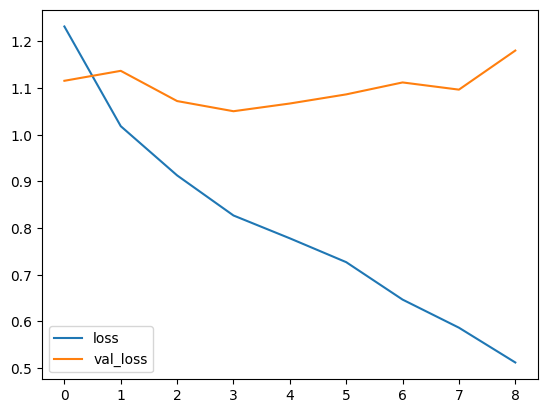

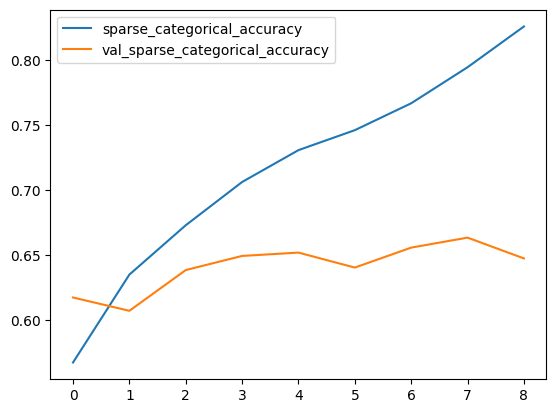

In [13]:
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['sparse_categorical_accuracy', 'val_sparse_categorical_accuracy']].plot()

In [14]:
loss, accuracy = base_model.evaluate(X_test, y_test)
print(loss)
print(accuracy)

310/313 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.1307 - sparse_categorical_accuracy: 0.6154

I0000 00:00:1727461663.364875    2196 tpu_compilation_cache_interface.cc:441] TPU host compilation cache miss: cache_key(f36431891f5dba64:0:0), session_name()


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 1.1305 - sparse_categorical_accuracy: 0.6154
1.1178343296051025
0.6128000020980835


I0000 00:00:1727461666.822585    2196 tpu_compile_op_common.cc:245] Compilation of f36431891f5dba64:0:0 with session name  took 3.45766953s and succeeded
I0000 00:00:1727461666.845647    2196 tpu_compilation_cache_interface.cc:475] TPU host compilation cache: compilation complete for cache_key(f36431891f5dba64:0:0), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_iterator_4719410740834710147", property.function_library_fingerprint = 783117859426156402, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z = false, std::string(property.shapes_prefix) = "2,32,32,3,;2,1,;", property.guaranteed_constants_size = 0, embedding_partitions_fingerprint = "1688352644216761960")
I0000 00:00:1727461666.845678    2196 tpu_compilation_cache_interface.cc:541] After adding entry for key f36431

# Hyperparameter tuning the head with Optuna

Create a new dense head of the CNN to work best with ResNet 50's convolutional base

In [15]:
def objective(trial):
    with strategy.scope():
#         resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
#         resnet.trainable = False
        
        densenet = DenseNet121(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
        densenet.trainable = False
        
#         vgg = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
#         vgg.trainable = False

#         efficient = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
#         efficient.trainable = False
        
        inputs = keras.Input(shape=(32, 32, 3))
        
#         x = resnet(inputs)
        x = densenet(inputs)
#         x = vgg(inputs)
#         x = efficient(inputs)
        
        x = layers.Flatten()(x)
        num_dense_neurons = trial.suggest_int('num_dense_neurons', 128, 512)
        x = layers.Dense(num_dense_neurons, activation='relu')(x)
        dense_dropout = trial.suggest_float('dense_dropout', .2, .5)
        x = layers.Dropout(dense_dropout)(x)
        
        output = layers.Dense(10)(x)
        
        tuned_model = keras.Model(inputs=inputs, outputs=output)
        
        tuned_model.compile(
            optimizer='adam',
            loss=SparseCategoricalCrossentropy(from_logits=True),
            metrics=['sparse_categorical_accuracy']
        )
        
        early_stopping = EarlyStopping(
            patience=5,
            min_delta=.001,
            restore_best_weights=True
        )
        
        history = tuned_model.fit(
            X_train, y_train,
            validation_data=(X_valid, y_valid),
            callbacks=[early_stopping],
            epochs=100
        )
        
        score = tuned_model.evaluate(X_valid, y_valid)
        
        return score[1]

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2024-09-27 18:27:53,560] A new study created in memory with name: no-name-d9f0d792-e1d2-4ec2-bc46-83d32786a932


Epoch 1/100


2024-09-27 18:28:14.915142: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node StatefulPartitionedCall.
I0000 00:00:1727461696.293565    2234 tpu_compilation_cache_interface.cc:441] TPU host compilation cache miss: cache_key(57de7cb032fd1e90:0:0), session_name()


   6/1172 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - loss: 2.7734 - sparse_categorical_accuracy: 0.2326  

I0000 00:00:1727461701.186609    2234 tpu_compile_op_common.cc:245] Compilation of 57de7cb032fd1e90:0:0 with session name  took 4.893007107s and succeeded
I0000 00:00:1727461701.216387    2234 tpu_compilation_cache_interface.cc:475] TPU host compilation cache: compilation complete for cache_key(57de7cb032fd1e90:0:0), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_iterator_5916543006266036264", property.function_library_fingerprint = 4034755402745332766, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z = false, std::string(property.shapes_prefix) = "4,32,32,3,;4,1,;", property.guaranteed_constants_size = 0, embedding_partitions_fingerprint = "1688352644216761960")
I0000 00:00:1727461701.216416    2234 tpu_compilation_cache_interface.cc:541] After adding entry for key 57de

...

   7/1172 ━━━━━━━━━━━━━━━━━━━━ 23s 20ms/step - loss: 3.4194 - sparse_categorical_accuracy: 0.1702  

I0000 00:00:1727467932.141306    2218 tpu_compile_op_common.cc:245] Compilation of 466c562d0b86fc25:0:0 with session name  took 5.383106789s and succeeded
I0000 00:00:1727467932.176958    2218 tpu_compilation_cache_interface.cc:475] TPU host compilation cache: compilation complete for cache_key(466c562d0b86fc25:0:0), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_iterator_2860528014296324050", property.function_library_fingerprint = 12216174349845641550, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z = false, std::string(property.shapes_prefix) = "4,32,32,3,;4,1,;", property.guaranteed_constants_size = 0, embedding_partitions_fingerprint = "1688352644216761960")
I0000 00:00:1727467932.176995    2218 tpu_compilation_cache_interface.cc:541] After adding entry for key 466

1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.6497 - sparse_categorical_accuracy: 0.4490

I0000 00:00:1727467960.497424    2191 tpu_compilation_cache_interface.cc:441] TPU host compilation cache miss: cache_key(3bf303ac47ce77e9:0:0), session_name()
I0000 00:00:1727467965.636548    2191 tpu_compile_op_common.cc:245] Compilation of 3bf303ac47ce77e9:0:0 with session name  took 5.139090115s and succeeded
I0000 00:00:1727467965.662660    2191 tpu_compilation_cache_interface.cc:475] TPU host compilation cache: compilation complete for cache_key(3bf303ac47ce77e9:0:0), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_iterator_6151954540085902345", property.function_library_fingerprint = 7645232619879618593, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z = false, std::string(property.shapes_prefix) = "4,32,32,3,;4,1,;", property.guaranteed_constants_size = 0, embeddin

1172/1172 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - loss: 1.6495 - sparse_categorical_accuracy: 0.4491 - val_loss: 1.1705 - val_sparse_categorical_accuracy: 0.5861
Epoch 2/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - loss: 1.2237 - sparse_categorical_accuracy: 0.5699 - val_loss: 1.0932 - val_sparse_categorical_accuracy: 0.6283
Epoch 3/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - loss: 1.1377 - sparse_categorical_accuracy: 0.5949 - val_loss: 1.1010 - val_sparse_categorical_accuracy: 0.6200
Epoch 4/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 35s 29ms/step - loss: 1.1083 - sparse_categorical_accuracy: 0.6114 - val_loss: 1.0488 - val_sparse_categorical_accuracy: 0.6475
Epoch 5/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - loss: 1.0806 - sparse_categorical_accuracy: 0.6225 - val_loss: 1.0453 - val_sparse_categorical_accuracy: 0.6417
Epoch 6/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - loss: 1.0163 - sparse_categorical_accuracy: 0.6492 - val_loss: 1.0442 - val_sparse_categorical_acc

In [ ]:
print(study.best_params)

# Scores for different pretrained models

ResNet50 averaged around 30%
DenseNet121 averaged around 65%
VGG averaged around 62%
EfficientNetB0 sucks